# Demo 1b: Torchvision Transforms & DataLoaders

Image preprocessing pipelines with `torchvision.transforms`, data
augmentation, and DataLoaders that feed batches to models.

**Dataset**: Oxford Flowers102 — 102 categories of common UK flowers.
High-resolution natural images that show augmentation effects clearly.

## Setup

In [ ]:
import matplotlib.pyplot as plt
import torch
from torchvision import transforms, datasets
from torch.utils.data import DataLoader, ConcatDataset
from PIL import Image
import numpy as np

device = torch.device(
    "cuda"
    if torch.cuda.is_available()
    else "mps"
    if torch.backends.mps.is_available()
    else "cpu"
)
print(f"Using device: {device}")

Using device: mps


## 1. Transform Pipelines

Transforms are composable — chain them together with `Compose` to build a
preprocessing pipeline.

In [ ]:
# Training transforms: augmentation + normalization
train_transform = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.RandomResizedCrop(224, scale=(0.6, 1.0)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(20),
    transforms.ColorJitter(
        brightness=0.3, contrast=0.3, saturation=0.3, hue=0.1
    ),
    transforms.RandomPerspective(distortion_scale=0.2, p=0.3),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
])

# Evaluation transforms: deterministic resize + normalize only
eval_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
])

print("Train transform pipeline:")
for i, t in enumerate(train_transform.transforms):
    print(f"  {i + 1}. {t}")

Train transform pipeline:
  1. Resize(size=(256, 256), interpolation=bilinear, max_size=None, antialias=True)
  2. RandomResizedCrop(size=(224, 224), scale=(0.6, 1.0), ratio=(0.75, 1.3333), interpolation=bilinear, antialias=True)
  3. RandomHorizontalFlip(p=0.5)
  4. RandomRotation(degrees=[-20.0, 20.0], interpolation=nearest, expand=False, fill=0)
  5. ColorJitter(brightness=(0.7, 1.3), contrast=(0.7, 1.3), saturation=(0.7, 1.3), hue=(-0.1, 0.1))
  6. RandomPerspective(p=0.3)
  7. ToTensor()
  8. Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])


## 2. Load Flowers102 Dataset

`Flowers102` has 102 flower species — sunflowers, roses, daisies, orchids,
and more. Images are high-resolution photos, perfect for seeing how
transforms affect real images.

In [ ]:
# Download and load the dataset (no transforms yet — we want raw images for viz)
raw_dataset = datasets.Flowers102(root="./data", split="train", download=True)
print(f"Training samples: {len(raw_dataset)}")

# Grab a sample image
sample_img, sample_label = raw_dataset[0]
print(f"Sample image size: {sample_img.size}, label: {sample_label}")

Training samples: 1020
Sample image size: (754, 500), label: 0


## 3. What Each Transform Does

Before combining transforms, it helps to see each one in isolation.
The parameters here are exaggerated so the effect is obvious.

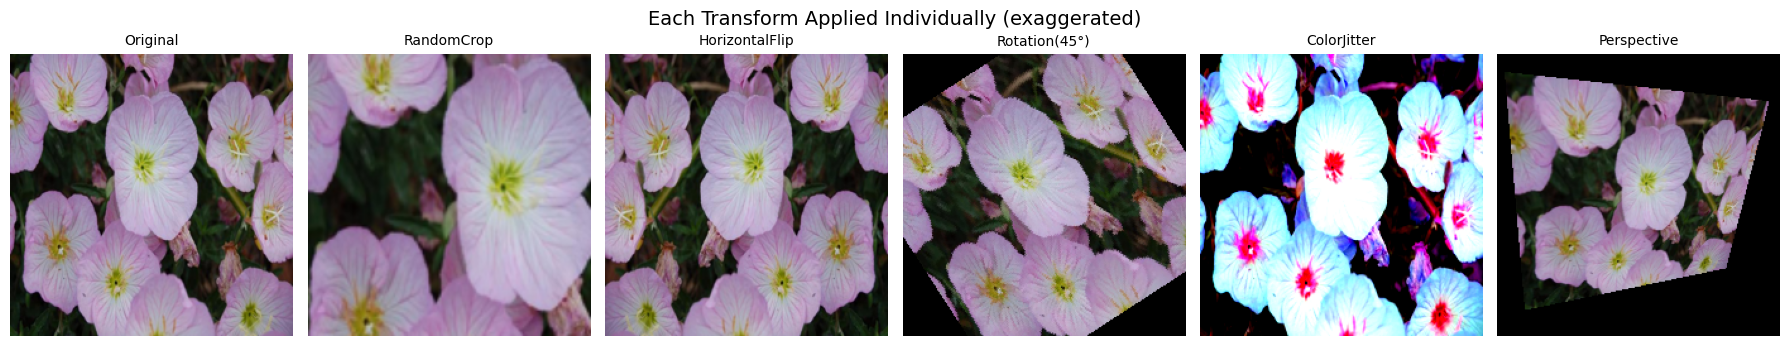

In [ ]:
# Apply each transform individually — parameters cranked up for visibility
base_img = sample_img.resize((224, 224))

step_transforms = [
    ("Original", None),
    ("RandomCrop", transforms.RandomResizedCrop(224, scale=(0.3, 0.5))),
    ("HorizontalFlip", transforms.RandomHorizontalFlip(p=1.0)),
    ("Rotation(45°)", transforms.RandomRotation(45)),
    (
        "ColorJitter",
        transforms.ColorJitter(
            brightness=0.8, contrast=0.8, saturation=0.8, hue=0.3
        ),
    ),
    ("Perspective", transforms.RandomPerspective(distortion_scale=0.5, p=1.0)),
]

fig, axes = plt.subplots(1, len(step_transforms), figsize=(18, 3.5))
for ax, (name, tfm) in zip(axes, step_transforms):
    if tfm is None:
        ax.imshow(base_img)
    else:
        ax.imshow(tfm(base_img))
    ax.set_title(name, fontsize=10)
    ax.axis("off")
plt.suptitle("Each Transform Applied Individually (exaggerated)", fontsize=14)
plt.tight_layout()
plt.show()

## 4. Combined Augmentations

In practice, transforms are chained together with `Compose`. Each call
produces a different random variant — this is how we create "new" training
examples from a single photo. We reuse the same transforms from above,
but with toned-down parameters suitable for actual training.

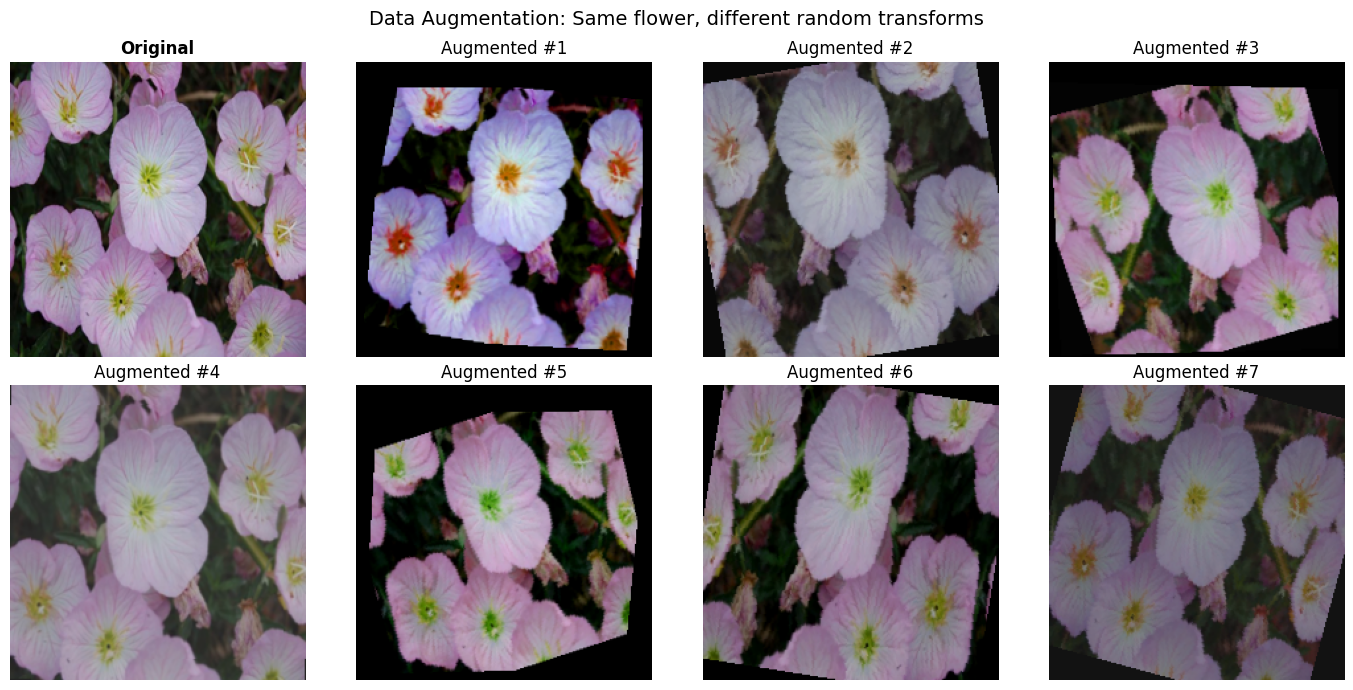

In [ ]:
# Reuse the same transform types, but with training-appropriate parameters
augment_viz = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.RandomResizedCrop(224, scale=(0.6, 1.0)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(20),
    transforms.ColorJitter(
        brightness=0.3, contrast=0.3, saturation=0.3, hue=0.1
    ),
    transforms.RandomPerspective(distortion_scale=0.2, p=0.3),
])

# Generate 8 augmented versions of the same flower
fig, axes = plt.subplots(2, 4, figsize=(14, 7))
for i, ax in enumerate(axes.flat):
    if i == 0:
        ax.imshow(sample_img.resize((224, 224)))
        ax.set_title("Original", fontweight="bold")
    else:
        augmented = augment_viz(sample_img)
        ax.imshow(augmented)
        ax.set_title(f"Augmented #{i}")
    ax.axis("off")
plt.suptitle(
    "Data Augmentation: Same flower, different random transforms", fontsize=14
)
plt.tight_layout()
plt.show()

## 5. Creating Datasets with Transforms

Now apply the full transform pipelines. `ImageFolder` expects a directory
where each subdirectory is a class:

```
data/my_images/
├── class_a/
│   ├── img_001.png
│   └── ...
└── class_b/
    ├── img_101.png
    └── ...
```

Flowers102 downloads automatically. For your own images, organize them
into this folder structure and use `ImageFolder`.

In [ ]:
# Flowers102 splits are oddly sized: "train" and "val" have 1,020 each,
# "test" has 6,149. Combine the two larger pools for training, hold out one for eval.
train_dataset = ConcatDataset([
    datasets.Flowers102(
        root="./data", split="test", download=True, transform=train_transform
    ),
    datasets.Flowers102(
        root="./data", split="val", download=True, transform=train_transform
    ),
])
test_dataset = datasets.Flowers102(
    root="./data", split="train", download=True, transform=eval_transform
)

print(f"Training samples: {len(train_dataset)}")
print(f"Test samples:     {len(test_dataset)}")

Training samples: 7169
Test samples:     1020


## 6. Building DataLoaders

DataLoaders handle batching, shuffling, and parallel data loading.

In [ ]:
train_loader = DataLoader(
    train_dataset,
    batch_size=32,
    shuffle=True,  # randomize order each epoch
    num_workers=2,  # parallel data loading (set 0 for debugging)
    pin_memory=True,  # faster CPU→GPU transfer
)
test_loader = DataLoader(
    test_dataset, batch_size=32, shuffle=False, num_workers=2
)

print(f"Batches per epoch: {len(train_loader)}")
print(f"Batch size: 32")

Batches per epoch: 225
Batch size: 32


In [ ]:
# Peek at a batch
images, labels = next(iter(train_loader))
print(f"Batch images shape: {images.shape}")  # (32, 3, 224, 224)
print(f"Batch labels shape: {labels.shape}")  # (32,)
print(
    f"Image dtype: {images.dtype}, range: [{images.min():.2f}, {images.max():.2f}]"
)

Batch images shape: torch.Size([32, 3, 224, 224])
Batch labels shape: torch.Size([32])
Image dtype: torch.float32, range: [-2.12, 2.64]


## 7. Visualizing a Batch

Since the images are normalized, we need to "un-normalize" them for display.
`torchvision.utils.make_grid` handles this with `normalize=True` — it
rescales the full value range to `[0, 1]` automatically.

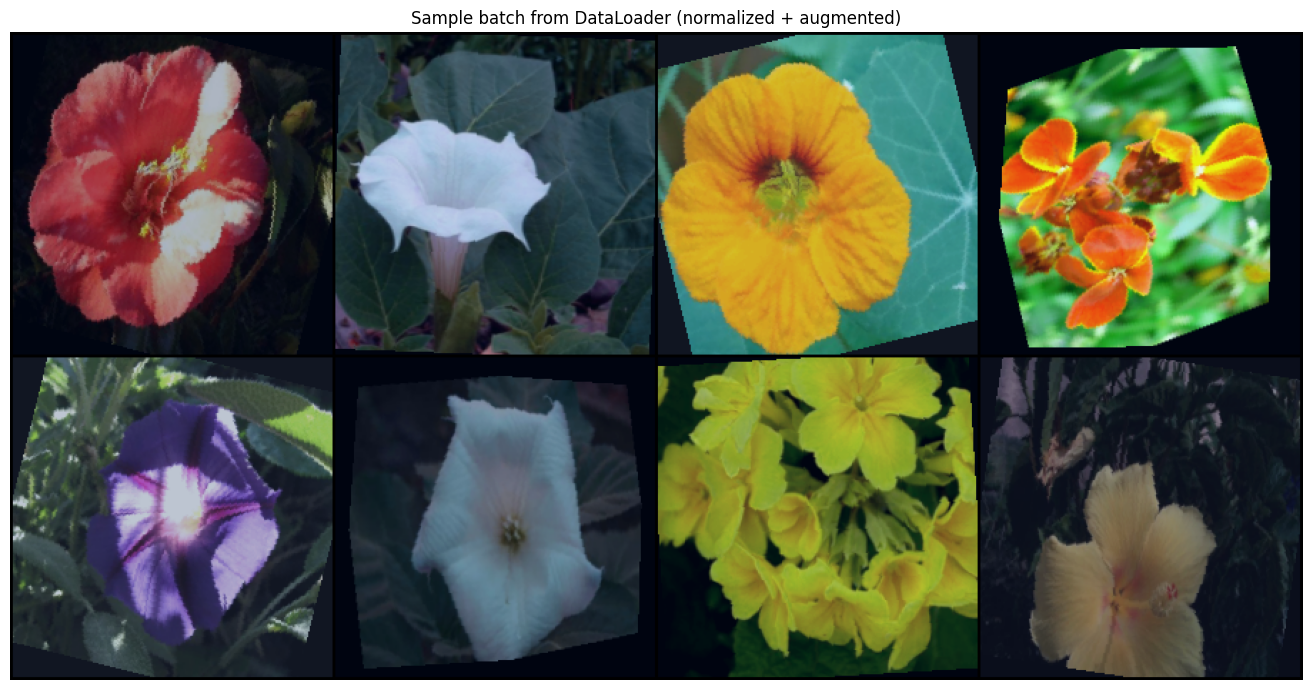

In [ ]:
from torchvision.utils import make_grid
from torchvision.transforms.functional import to_pil_image

# make_grid: batch → single image grid, normalize=True rescales for display
grid = make_grid(images[:8], nrow=4, normalize=True, padding=2)
plt.figure(figsize=(14, 7))
plt.imshow(to_pil_image(grid))
plt.title("Sample batch from DataLoader (normalized + augmented)")
plt.axis("off")
plt.tight_layout()
plt.show()

## 8. Train a Simple CNN

Now let's use those DataLoaders for real. We'll build the same `SimpleCNN`
from lecture — two conv blocks followed by a classifier — and train it on
Flowers102 for a few epochs.

102 classes is a lot for a tiny CNN. Don't expect great accuracy — the
point is to see the full pipeline: transforms → DataLoader → model → training
loop → evaluation. Demo 2 shows how transfer learning solves the accuracy
problem.

In [ ]:
import torch.nn as nn


class SimpleCNN(nn.Module):
    def __init__(self, num_classes=102):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),
            nn.AdaptiveAvgPool2d((
                4,
                4,
            )),  # collapse to 4×4 regardless of input size
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128 * 4 * 4, 256),
            nn.ReLU(inplace=True),
            nn.Dropout(0.5),
            nn.Linear(256, num_classes),
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x


model = SimpleCNN(num_classes=102).to(device)
print(f"Parameters: {sum(p.numel() for p in model.parameters()):,}")

Parameters: 644,454


In [ ]:
# The five-step training loop from lecture
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

num_epochs = 5
history = {"train_loss": [], "train_acc": [], "test_loss": [], "test_acc": []}

for epoch in range(num_epochs):
    # --- Training ---
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    for inputs, labels in train_loader:
        inputs, labels = inputs.to(device), labels.to(device)

        optimizer.zero_grad()  # 1. clear old gradients
        outputs = model(inputs)  # 2. forward pass
        loss = criterion(outputs, labels)  # 3. compute loss
        loss.backward()  # 4. backpropagation
        optimizer.step()  # 5. update weights

        running_loss += loss.item()
        correct += (outputs.argmax(1) == labels).sum().item()
        total += labels.size(0)

    history["train_loss"].append(running_loss / len(train_loader))
    history["train_acc"].append(correct / total)

    # --- Evaluation ---
    model.eval()
    test_loss = 0.0
    correct = 0
    total = 0
    with torch.no_grad():
        for inputs, labels in test_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            test_loss += criterion(outputs, labels).item()
            correct += (outputs.argmax(1) == labels).sum().item()
            total += labels.size(0)

    history["test_loss"].append(test_loss / len(test_loader))
    history["test_acc"].append(correct / total)

    print(
        f"Epoch {epoch + 1}/{num_epochs} — "
        f"Train Loss: {history['train_loss'][-1]:.4f}, Train Acc: {history['train_acc'][-1]:.1%}, "
        f"Test Loss: {history['test_loss'][-1]:.4f}, Test Acc: {history['test_acc'][-1]:.1%}"
    )

print(
    f"\nRandom guessing would be ~1%. Demo 2 shows how transfer learning does much better."
)

Epoch 1/5 — Train Loss: 4.2346, Train Acc: 6.6%, Test Loss: 4.0842, Test Acc: 5.8%
Epoch 2/5 — Train Loss: 3.8667, Train Acc: 10.3%, Test Loss: 3.8186, Test Acc: 8.8%
Epoch 3/5 — Train Loss: 3.7152, Train Acc: 11.5%, Test Loss: 3.5948, Test Acc: 13.0%
Epoch 4/5 — Train Loss: 3.5961, Train Acc: 12.3%, Test Loss: 3.3746, Test Acc: 14.4%
Epoch 5/5 — Train Loss: 3.5244, Train Acc: 13.3%, Test Loss: 3.3655, Test Acc: 15.8%

Random guessing would be ~1%. Demo 2 shows how transfer learning does much better.


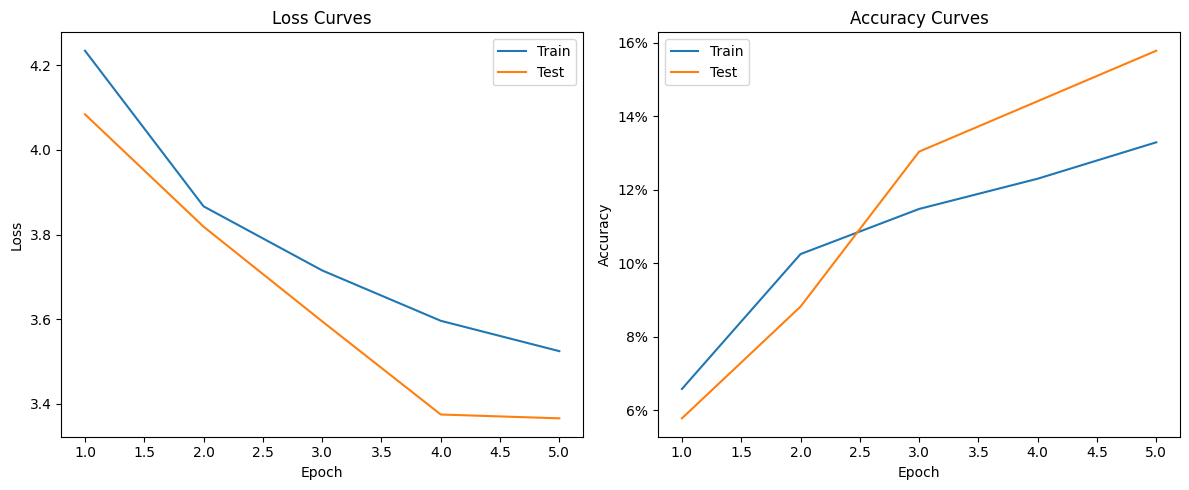

In [ ]:
# Plot training curves
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
epochs = range(1, num_epochs + 1)

ax1.plot(epochs, history["train_loss"], label="Train")
ax1.plot(epochs, history["test_loss"], label="Test")
ax1.set_xlabel("Epoch")
ax1.set_ylabel("Loss")
ax1.set_title("Loss Curves")
ax1.legend()

ax2.plot(epochs, history["train_acc"], label="Train")
ax2.plot(epochs, history["test_acc"], label="Test")
ax2.set_xlabel("Epoch")
ax2.set_ylabel("Accuracy")
ax2.set_title("Accuracy Curves")
ax2.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f"{y:.0%}"))
ax2.legend()

plt.tight_layout()
plt.show()